In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [33]:
df = pd.read_csv('../results_data/epoch_table.csv')

summary = (
    df.groupby("optimizer")["epoch"]
    .agg(["mean", "std"])
    .reset_index()
)

# Save table
summary.to_csv("epochs_summary.csv", index=False)

print(summary)

   optimizer        mean        std
0    adagrad   26.333333  15.631165
1       adam   24.333333   0.577350
2      adamw   26.333333  11.846237
3      adamx   13.200000   4.494441
4       adan   38.000000  21.166010
5    amsgrad    9.666667   0.577350
6       lion   35.333333  32.516662
7      radam   26.333333  17.616280
8    rmsprop  100.000000   0.000000
9        sgd  100.000000   0.000000
10      yogi    9.333333   2.081666


C:\Users\Francisco\AppData\Local\Temp\ipykernel_9108\119185890.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
C:\Users\Francisco\AppData\Local\Temp\ipykernel_9108\119185890.py:20: UserWarning: The palette list has more values (12) than needed (11), which may not be intended.
  ax = sns.barplot(


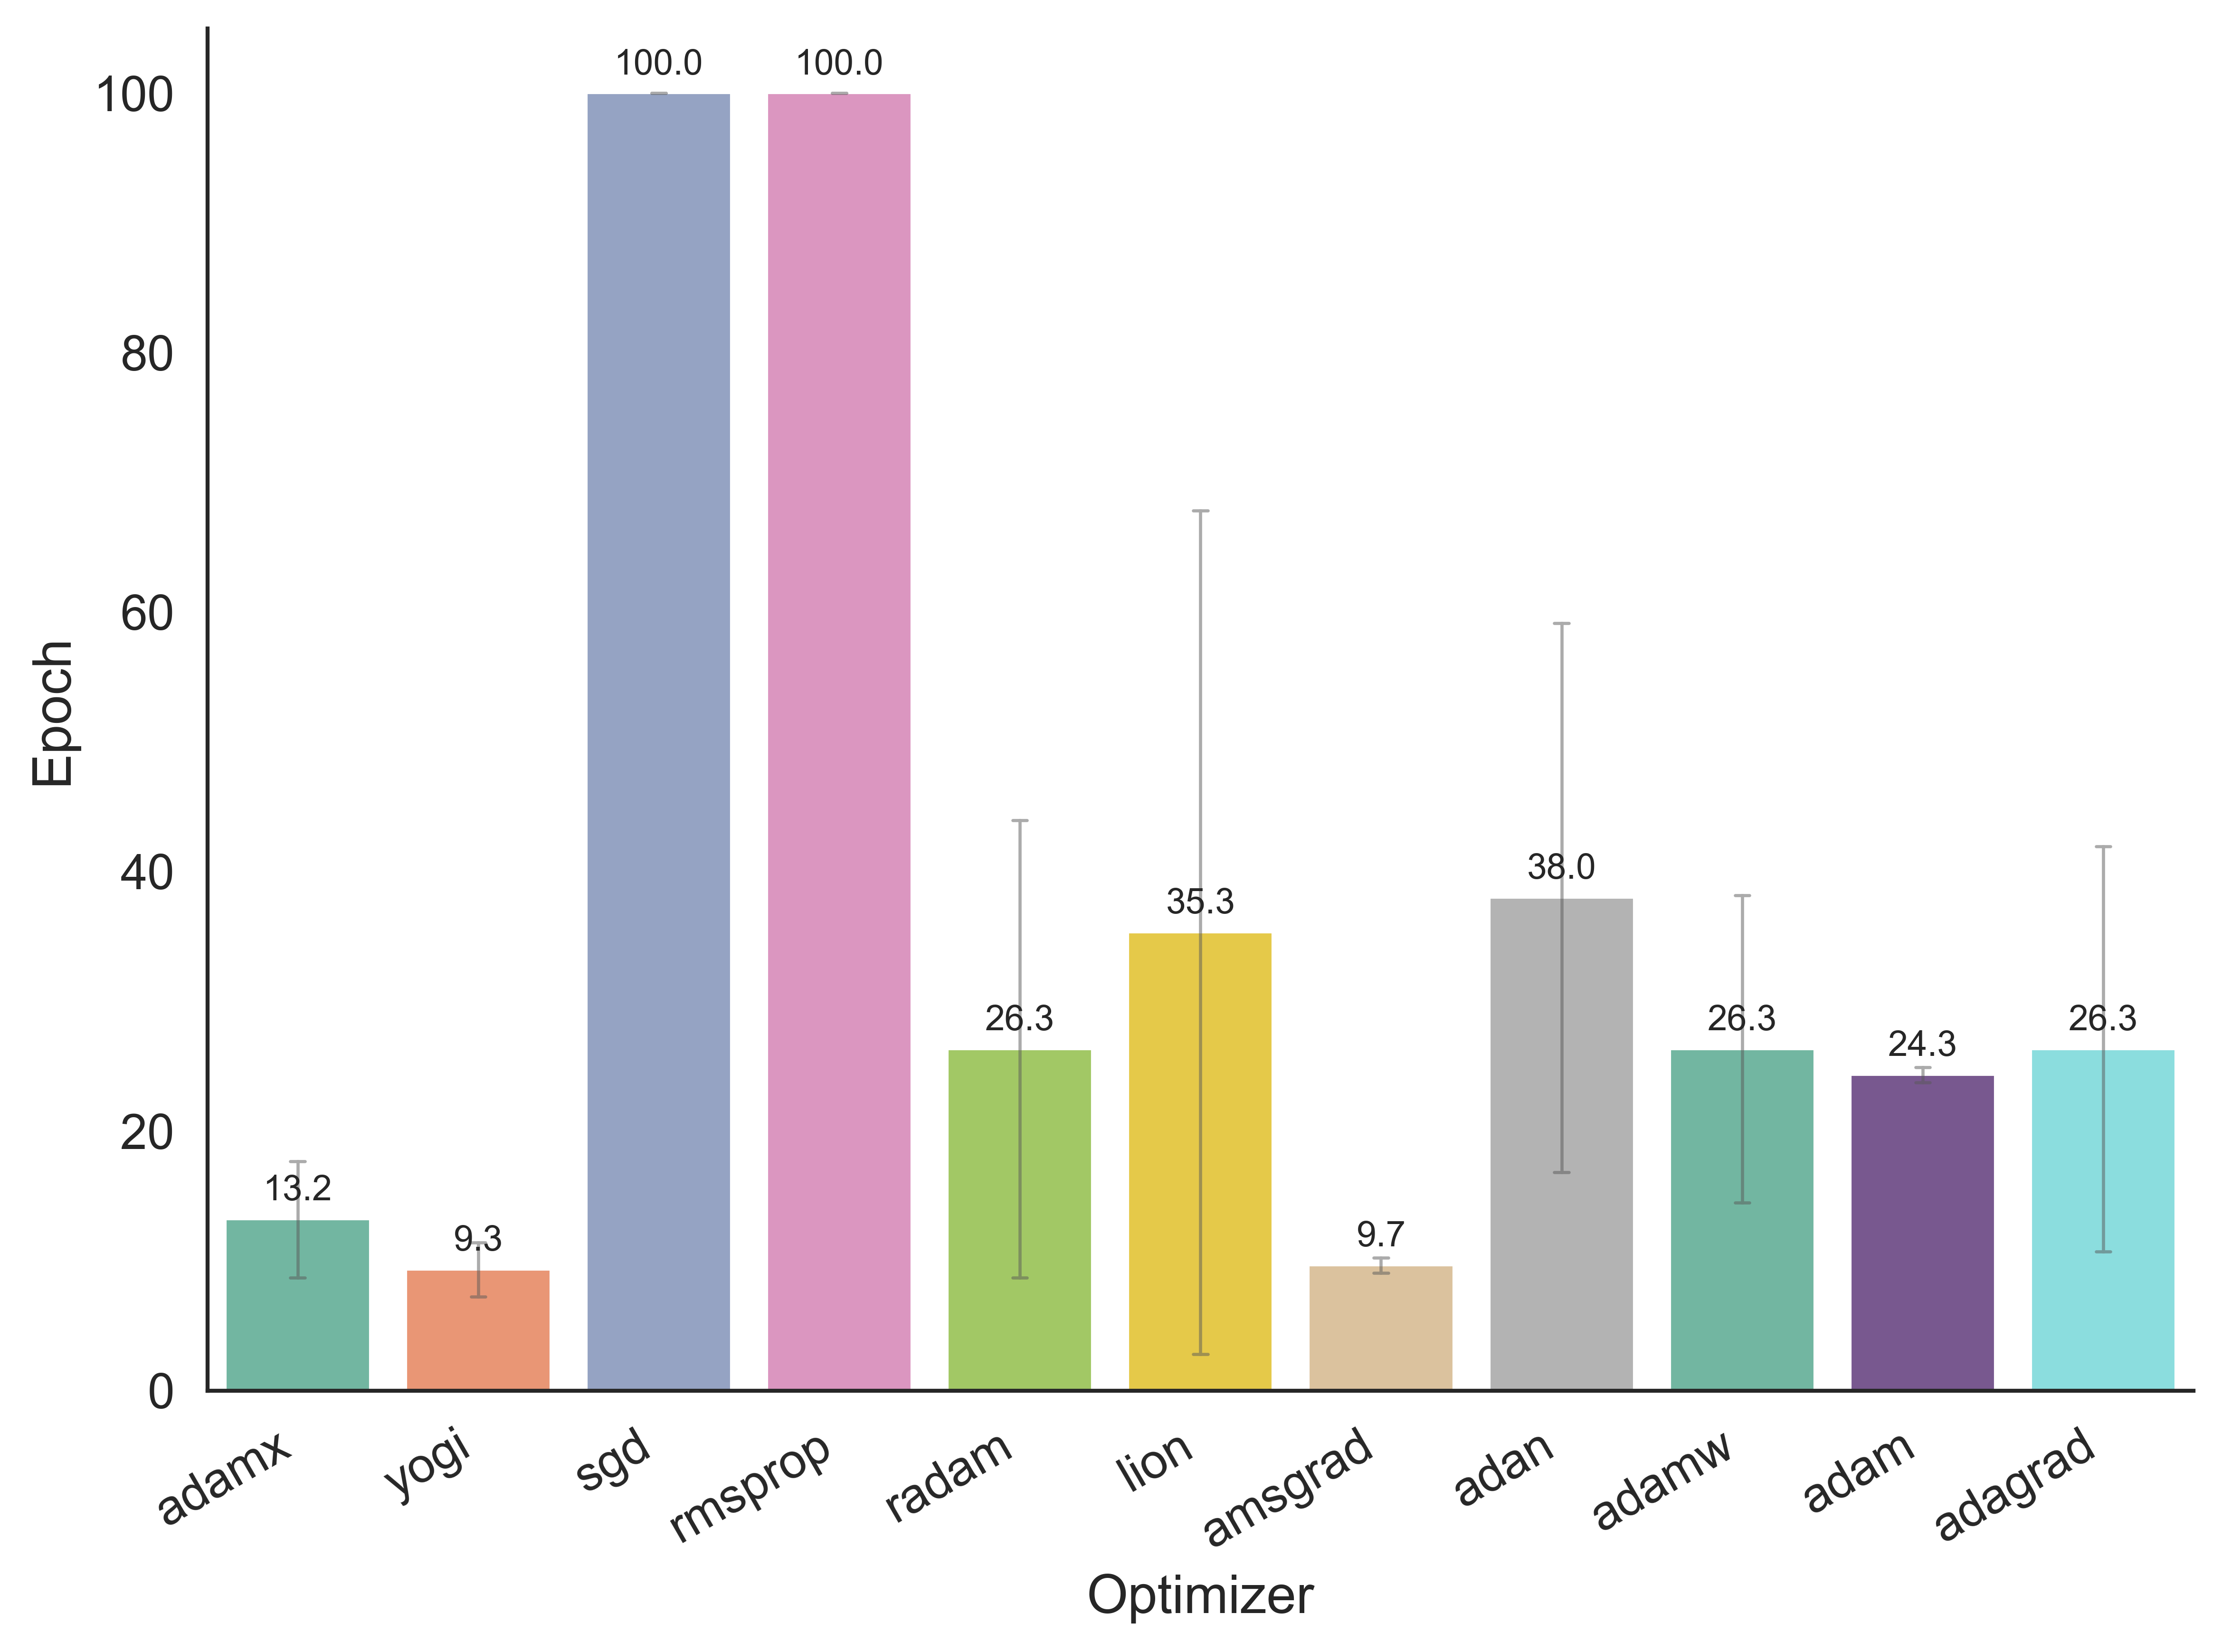

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    style="white",
    context="paper",
    font_scale=1.4
)

plt.figure(figsize=(8, 6), dpi=600)
base = sns.color_palette("Set2", 9)

extra = [
    "#7A4F98",  # indigo (deep purple-blue)
    "#7DEAECFF",  # dark turquoise
    "#F2E391FF"   # gold
]

colors = list(base) + extra
ax = sns.barplot(
    data=df,
    x="optimizer",
    y="epoch",
    errorbar="sd",
    palette=colors,
    linewidth=0.5,
    err_kws={
        "color": "0.35",     # softer gray
        "alpha": 0.5,        # transparency
        "linewidth": 0.8     # thinner lines
    },
    capsize=0.08
)

# Rotate labels
plt.xticks(rotation=30, ha="right")

# Add values on top of bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height:.1f}",
        (p.get_x() + p.get_width() / 2., height),
        ha="center",
        va="bottom",
        fontsize=9,
        xytext=(0, 3),
        textcoords="offset points"
    )

# Cleaner look
sns.despine()

ax.set_xlabel("Optimizer")
ax.set_ylabel("Epoch")

plt.tight_layout()

# Better for papers
plt.savefig("epochs_barplot.pdf", bbox_inches="tight")

plt.show()


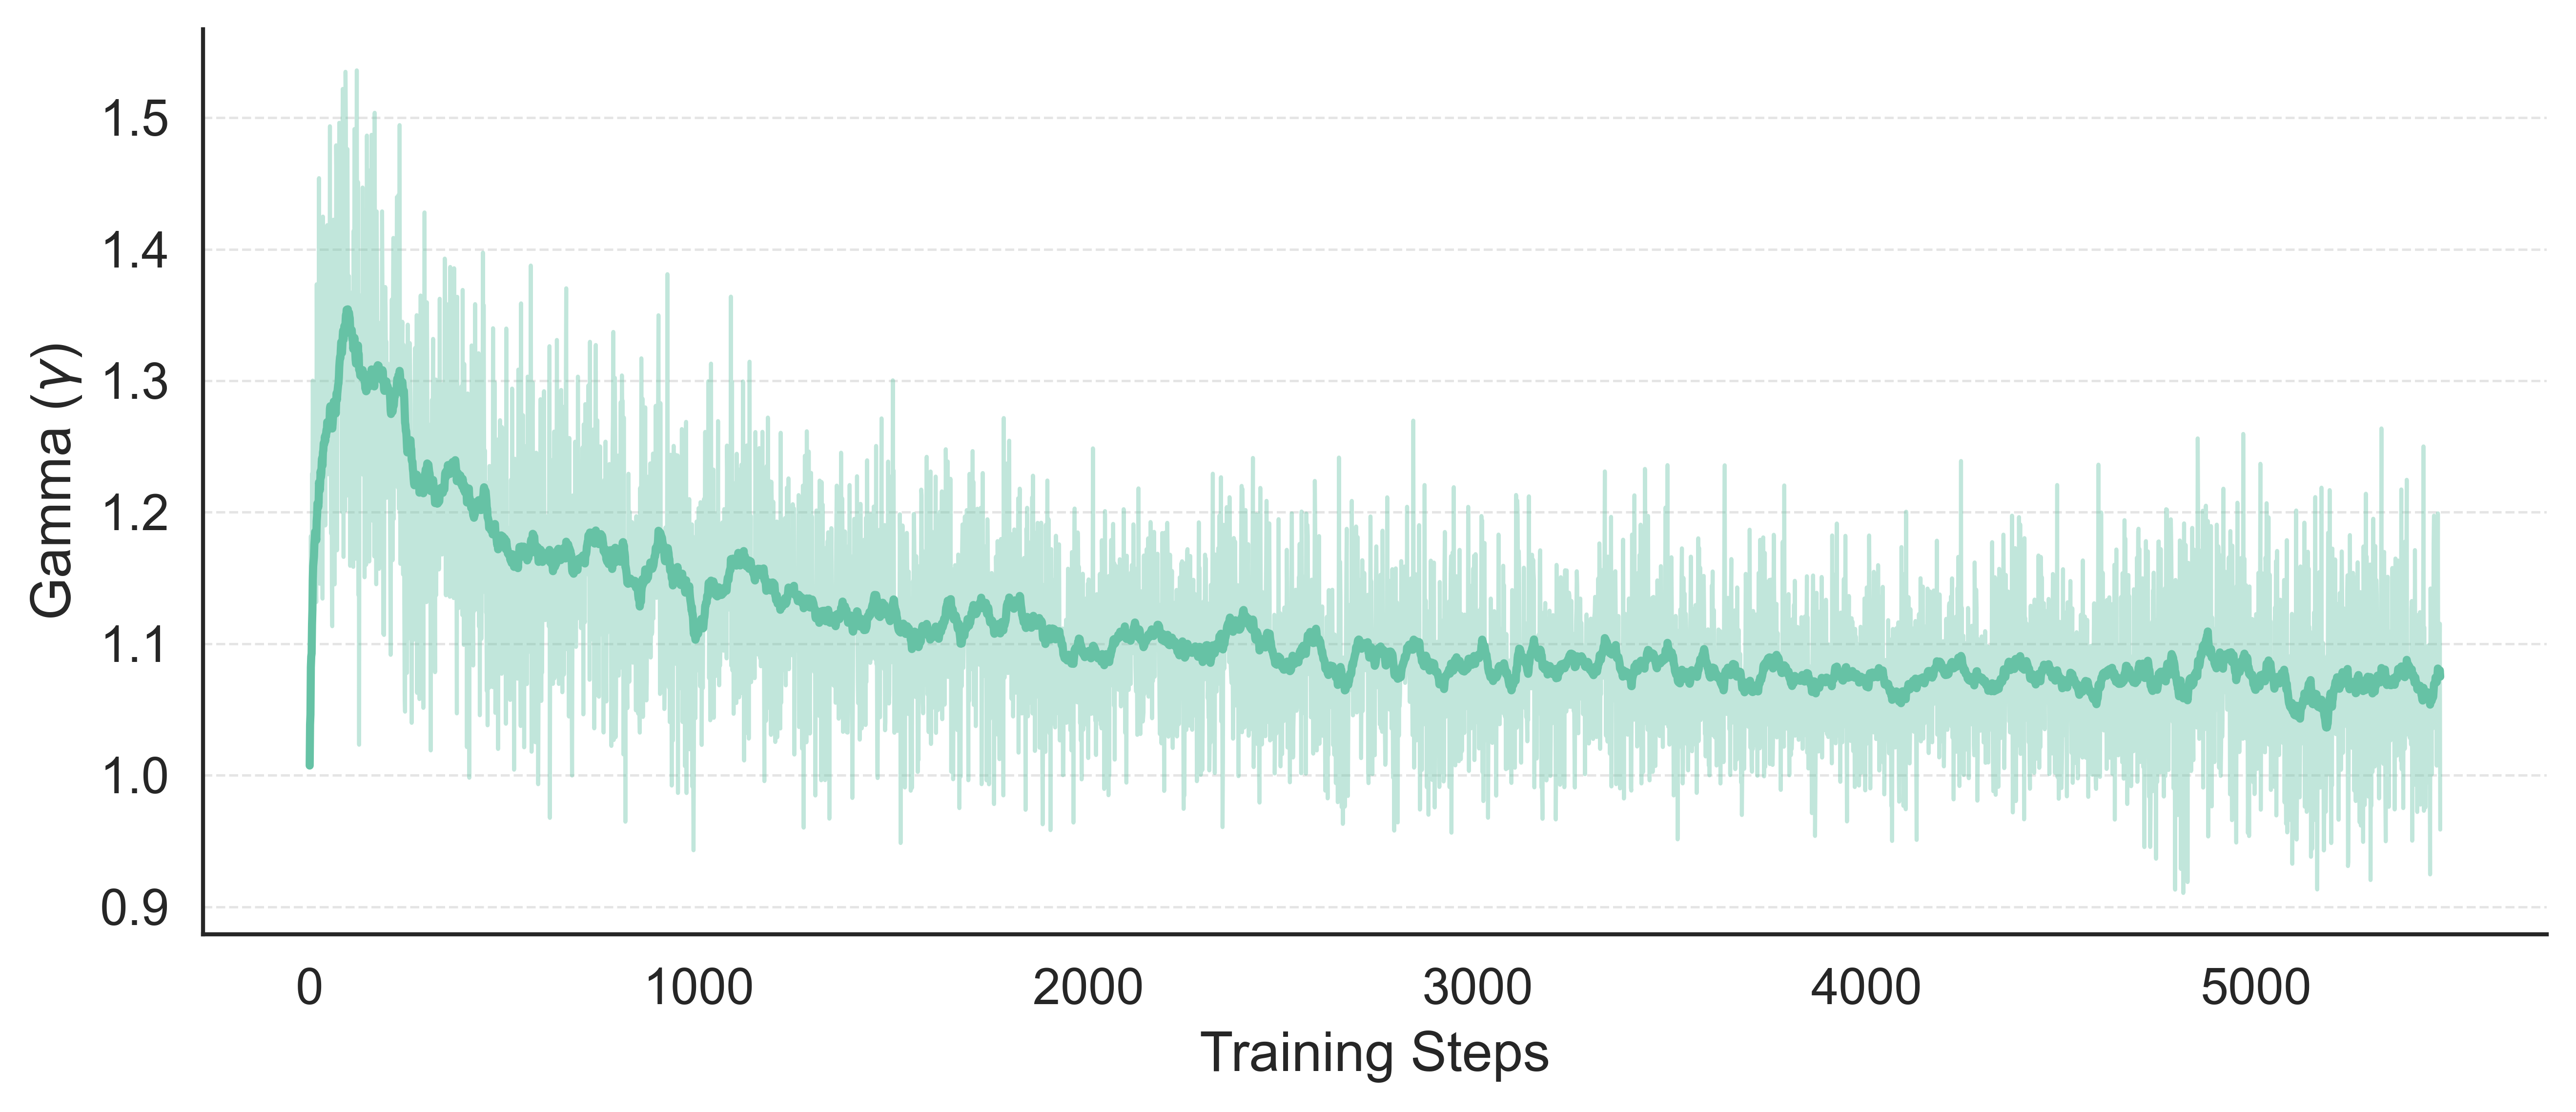

In [63]:
df_gamma = pd.read_csv('gamma_cifar_average.csv')

fig, ax = plt.subplots(figsize=(9, 4), dpi=600)
gamma = df_gamma.iloc[:, 1]
ax.plot(gamma,
        color=colors[0],
        linewidth=1,alpha=0.4)
gamma_smooth = gamma.ewm(span=50).mean()
ax.plot(gamma_smooth,
        color=colors[0],
        linewidth=2,
        alpha=1)
sns.despine()
ax.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.5)
ax.set_xlabel("Training Steps")
ax.set_ylabel('Gamma '+r'($\gamma$)')

plt.tight_layout()

plt.savefig("gamma_plot.pdf", bbox_inches="tight")
plt.show()


In [4]:
df2 = pd.read_csv('epochs_summary_cifar.csv')

summary = (
    df2.groupby("optimizer")["epoch"]
    .agg(["mean", "std"])
    .reset_index()
)

# Save table
summary.to_csv("epochs_summary_cifa10.csv", index=False)

print(summary)

   optimizer   mean        std
0    adagrad  100.0        NaN
1       adam    9.6   5.856620
2      adamw   16.6  11.653326
3      adamx    6.6   0.547723
4       adan  100.0   0.000000
5    amsgrad    7.8   1.303840
6       lion  100.0        NaN
7      radam   30.2  24.933913
8    rmsprop   24.2  28.943048
9        sgd  100.0   0.000000
10      yogi  100.0   0.000000


C:\Users\Francisco\AppData\Local\Temp\ipykernel_16112\1608197507.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
C:\Users\Francisco\AppData\Local\Temp\ipykernel_16112\1608197507.py:20: UserWarning: The palette list has more values (12) than needed (11), which may not be intended.
  ax = sns.barplot(


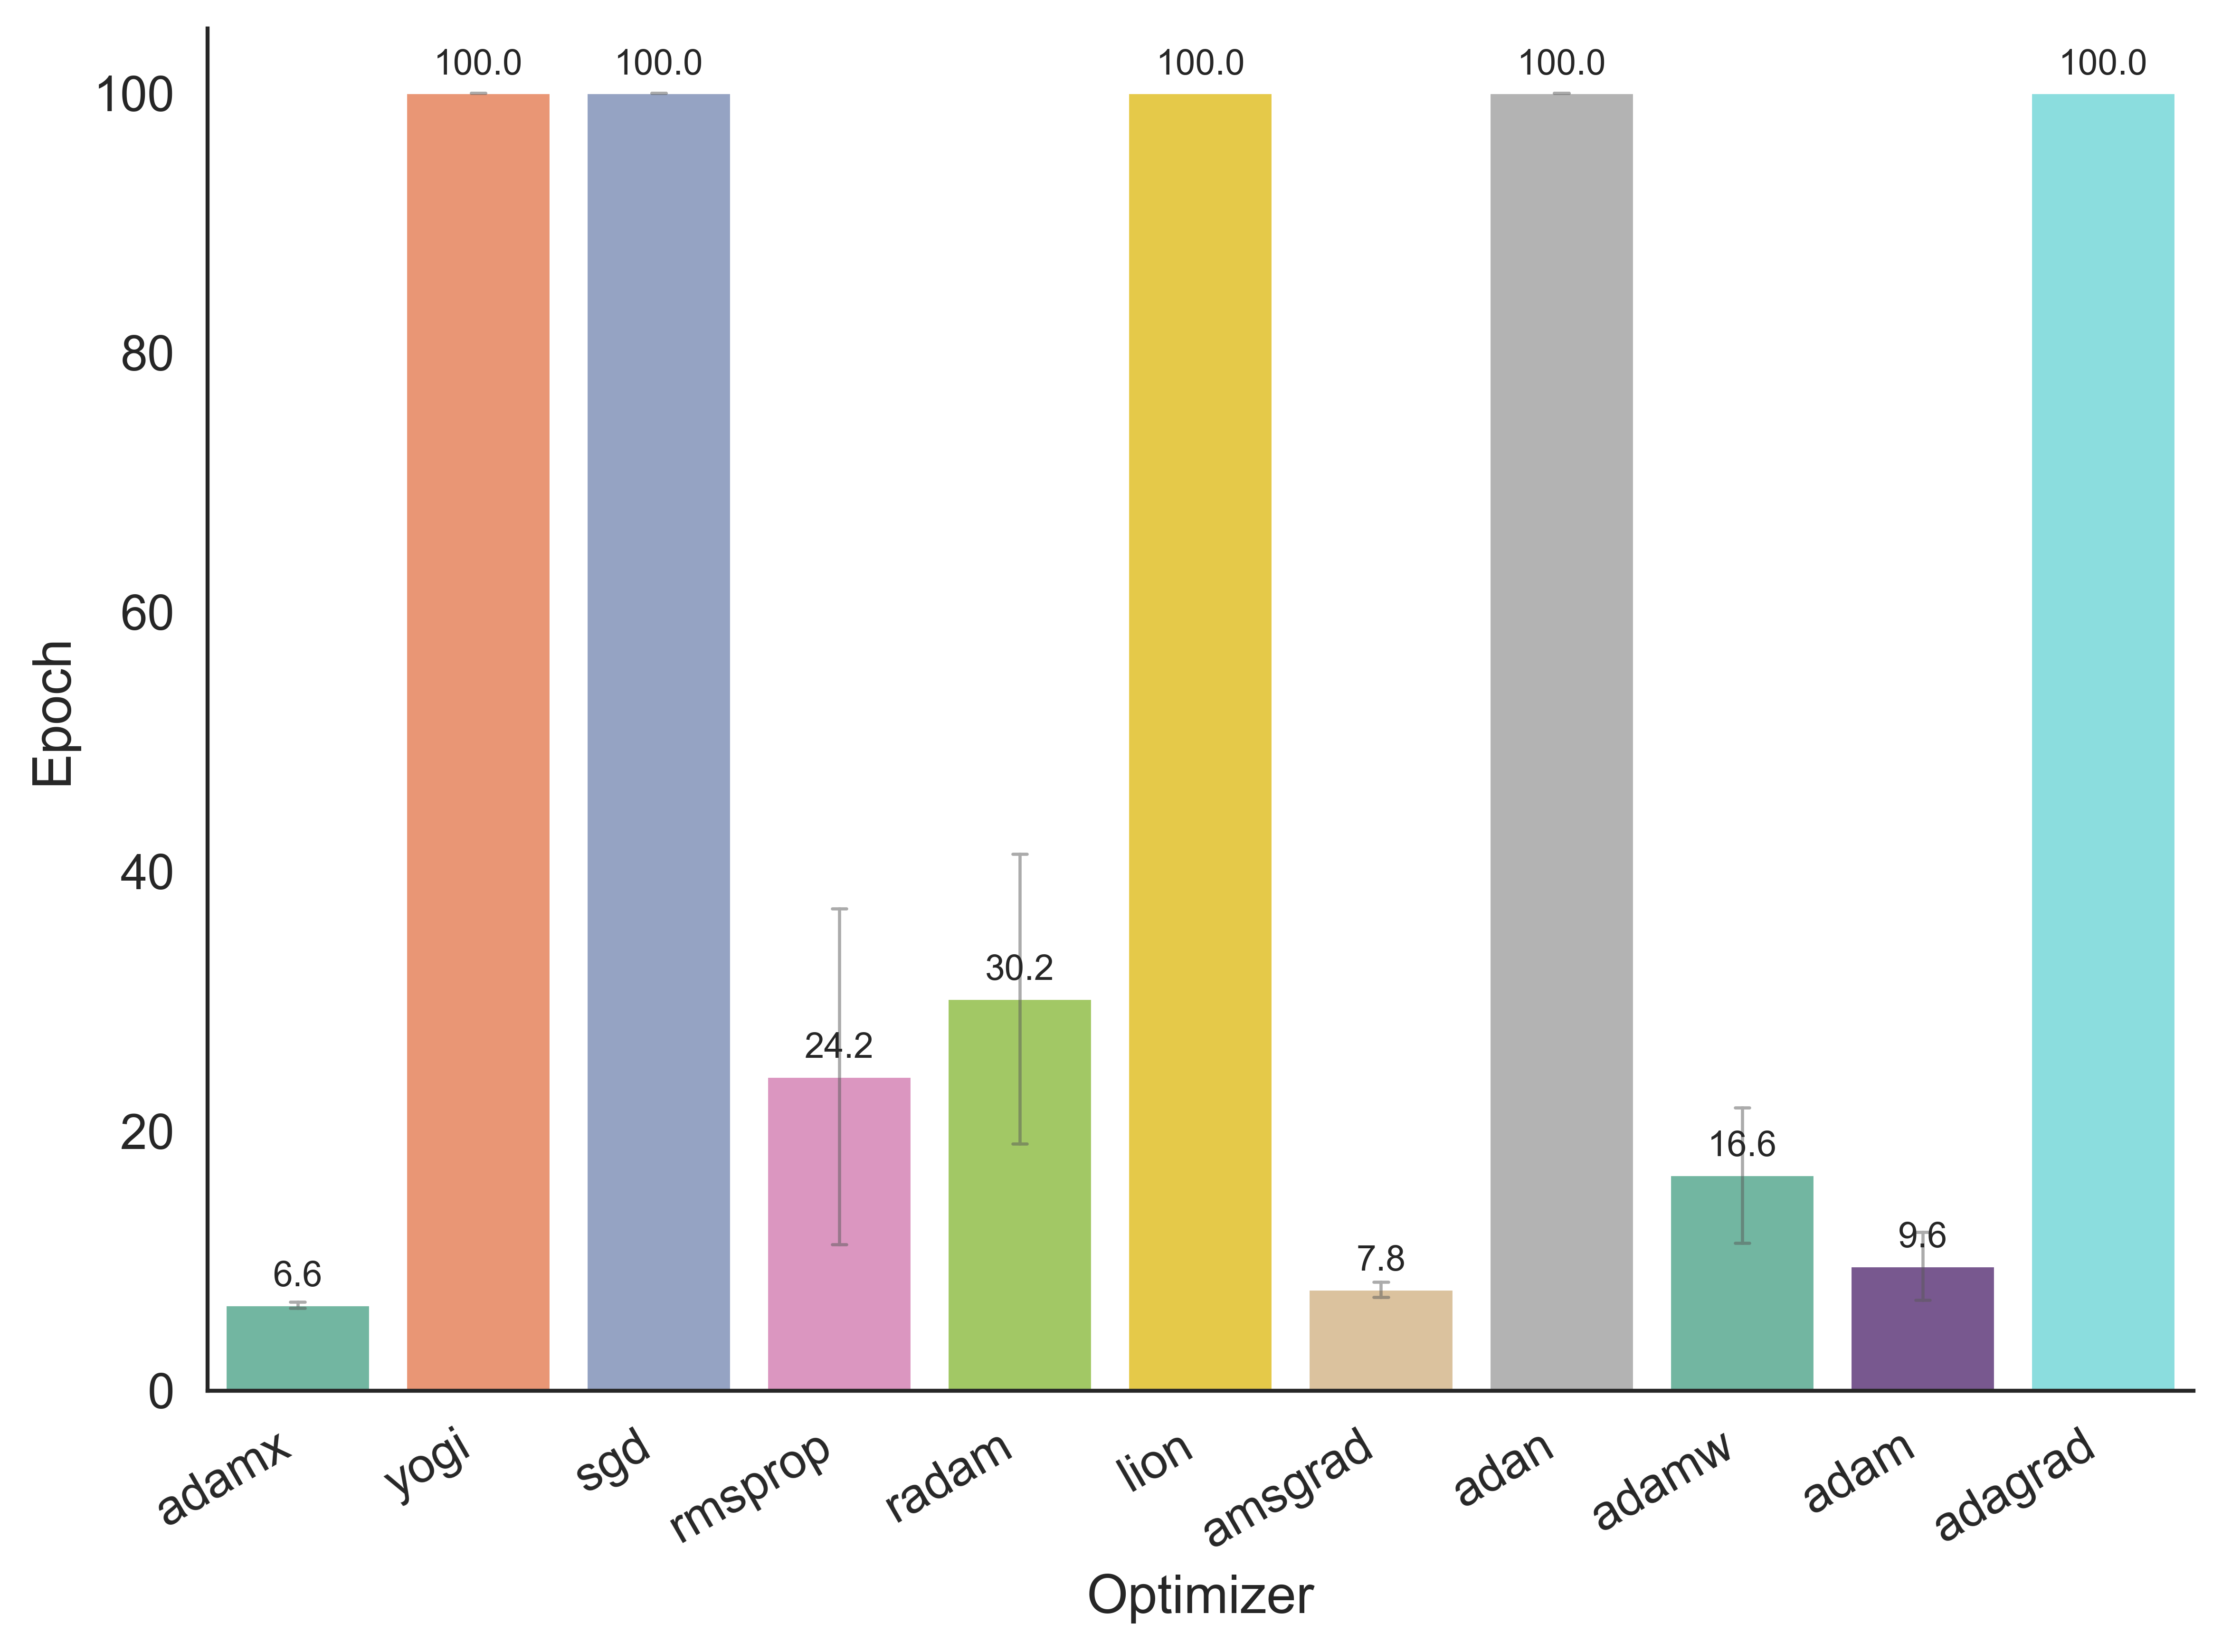

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    style="white",
    context="paper",
    font_scale=1.4
)

plt.figure(figsize=(8, 6), dpi=600)
base = sns.color_palette("Set2", 9)

extra = [
    "#7A4F98",  # indigo (deep purple-blue)
    "#7DEAECFF",  # dark turquoise
    "#F2E391FF"   # gold
]

colors = list(base) + extra
ax = sns.barplot(
    data=df2,
    x="optimizer",
    y="epoch",
    errorbar="se",
    palette=colors,
    linewidth=0.5,
    order = [
    "adamx",
    "yogi",
    "sgd",
    "rmsprop",
    "radam",
    "lion",
    "amsgrad",
    "adan",
    "adamw",
    "adam",
    "adagrad",
],
    err_kws={
        "color": "0.35",     # softer gray
        "alpha": 0.5,        # transparency
        "linewidth": 0.8     # thinner lines
    },
    capsize=0.08
)

# Rotate labels
plt.xticks(rotation=30, ha="right")

# Add values on top of bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height:.1f}",
        (p.get_x() + p.get_width() / 2., height),
        ha="center",
        va="bottom",
        fontsize=9,
        xytext=(0, 3),
        textcoords="offset points"
    )

# Cleaner look
sns.despine()
#ax.set_ylim(bottom=0)
ax.set_xlabel("Optimizer")
ax.set_ylabel("Epoch")

plt.tight_layout()

# Better for papers
plt.savefig("epochs_barplot.pdf", bbox_inches="tight")

plt.show()
